In [1]:
import importlib, os, sys

if 'google.colab' in sys.modules and not os.path.exists('notebook_setup.py'):
    raise RuntimeError(
        'notebook_setup.py missing. Clone the repo first:\n'
        '  !git clone https://github.com/ericxu1070/invobs-data-assimilation /content/invobs\n'
        '  %cd /content/invobs'
    )

import notebook_setup as ns

ns.ensure_packages({
    'torch':      'torch',
    'numpy':      'numpy',
    'matplotlib': 'matplotlib',
})


Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


In [2]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

IN_COLAB  = ns.detect_colab()
CACHE_DIR = ns.setup_cache()
device = torch.device('cpu')  # MPS lacks rfft2 + bicubic + conv3d supportns.banner(CACHE_DIR, device, IN_COLAB)

torch.set_default_dtype(torch.float32)
torch.manual_seed(0)
np.random.seed(0)


In [3]:
from pytorch_invobs_lib import save_cache, load_cache
from pytorch_kolmogorov import (
    KolmogorovFlow,
    ObservationInverterKolmogorov,
    generate_kolmogorov_data,
)


In [4]:
# ── Experiment hyperparameters ───────────────────────────────────────
# System
NX, NY        = 64, 64
NU            = 1e-2
ALPHA         = 0.1
K_FORCING     = 4
OUTER_DT      = 0.18
N_INNER       = 25
OBSERVE_EVERY = 16   # -> 4x4 obs grid

# Assimilation window
T_ASSIM = 10

# Training data
N_TRAIN   = 500    # increase to 32000 on Colab GPU for paper-quality results
N_WARMUP  = 100    # outer steps discarded during spin-up
N_EPOCHS  = 50     # increase to 500 on Colab GPU
BATCH_SIZE = 8

# Test / DA
N_TEST      = 20   # increase to 100 on Colab GPU
OBS_NOISE_SIGMAS = [0.0, 0.1, 0.5]  # noise levels to sweep

# Optimiser
LBFGS_STEPS_OBS    = 400
LBFGS_STEPS_PHYS   = 100
LBFGS_STEPS_HYBRID = 400   # obs steps after physics phase

print('Hyperparameters set.')
print(f'  Training trajectories : {N_TRAIN}')
print(f'  Epochs                : {N_EPOCHS}')
print(f'  Test trajectories     : {N_TEST}')


Hyperparameters set.
  Training trajectories : 500
  Epochs                : 50
  Test trajectories     : 20


In [5]:
# Force CPU for KolmogorovFlow — torch.fft.rfft2 not yet on MPS
kf_device = torch.device('cpu')

kf = KolmogorovFlow(
    Nx=NX, Ny=NY, nu=NU, alpha=ALPHA,
    k_forcing=K_FORCING, outer_dt=OUTER_DT, n_inner=N_INNER,
    observe_every=OBSERVE_EVERY, device=device,
)
print('KolmogorovFlow system ready.')
print(f'  Grid          : {NX}x{NY}')
print(f'  Obs grid      : {NX//OBSERVE_EVERY}x{NY//OBSERVE_EVERY}')
print(f'  Outer dt      : {OUTER_DT}  ({N_INNER} inner RK4 steps each)')

KolmogorovFlow system ready.
  Grid          : 64x64
  Obs grid      : 4x4
  Outer dt      : 0.18  (25 inner RK4 steps each)


In [6]:
TRAIN_CACHE = 'kf_train_data.pt'

data = load_cache(TRAIN_CACHE, CACHE_DIR)
if data is None:
    print(f'Generating {N_TRAIN} training trajectories (warmup={N_WARMUP}) ...')
    omega0_tr, traj_tr, Y_tr, Y_clean_tr = generate_kolmogorov_data(
        kf, n_samples=N_TRAIN, n_time_steps=T_ASSIM,
        n_warmup=N_WARMUP, obs_noise_std=0.0, seed=0,
    )
    data = dict(omega0=omega0_tr, traj=traj_tr, Y=Y_tr, Y_clean=Y_clean_tr)
    save_cache(data, TRAIN_CACHE, CACHE_DIR)
else:
    omega0_tr = data['omega0']
    traj_tr   = data['traj']
    Y_tr      = data['Y']
    Y_clean_tr= data['Y_clean']

print(f'Training data shapes:')
print(f'  omega0 : {omega0_tr.shape}')   # (N, 64, 64)
print(f'  traj   : {traj_tr.shape}')     # (N, T, 64, 64)
print(f'  Y      : {Y_tr.shape}')        # (N, T, 4, 4)


  [cache] loaded kf_train_data.pt
Training data shapes:
  omega0 : torch.Size([500, 64, 64])
  traj   : torch.Size([500, 10, 64, 64])
  Y      : torch.Size([500, 10, 4, 4])


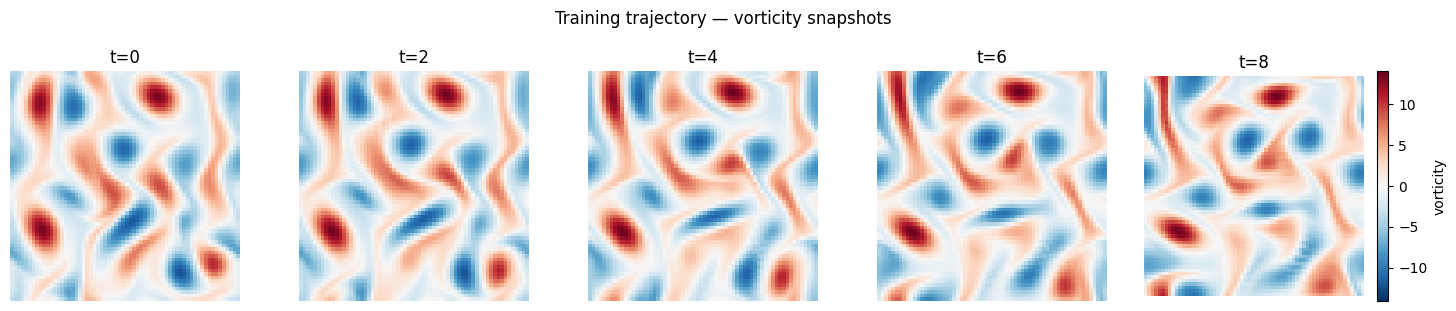

Vorticity range: [-12.25, 14.08]


In [7]:
# Quick sanity-check: plot vorticity snapshots for one trajectory
fig, axes = plt.subplots(1, 5, figsize=(15, 3))
traj_np = traj_tr[0].cpu().numpy()   # (T, 64, 64)
vmax = max(abs(traj_np.min()), abs(traj_np.max()))
for i, ax in enumerate(axes):
    t_idx = i * (T_ASSIM // 5)
    im = ax.imshow(traj_np[t_idx], cmap='RdBu_r',
                   vmin=-vmax, vmax=vmax, origin='lower')
    ax.set_title(f't={t_idx}')
    ax.axis('off')
plt.colorbar(im, ax=axes[-1], label='vorticity')
plt.suptitle('Training trajectory — vorticity snapshots', y=1.02)
plt.tight_layout()
plt.savefig('figures/kf_train_trajectory.png', dpi=100, bbox_inches='tight')
plt.show()
print('Vorticity range: [{:.2f}, {:.2f}]'.format(traj_np.min(), traj_np.max()))


In [ ]:
import torch.optim as optim

INVERTER_CACHE = f'kf_inverter_ep{N_EPOCHS}_n{N_TRAIN}.pt'

inverter = ObservationInverterKolmogorov(
    T=T_ASSIM, obs_grid=NX // OBSERVE_EVERY,
    full_grid=NX, in_channels=1, out_channels=1,
).to(device)

inverter_data = load_cache(INVERTER_CACHE, CACHE_DIR)
if inverter_data is not None:
    inverter.load_state_dict(inverter_data['state_dict'])
    train_losses = inverter_data['train_losses']
    print(f'Loaded cached inverter (final loss {train_losses[-1]:.4f})')
else:
    print(f'Training inverter for {N_EPOCHS} epochs ...')
    optimizer = optim.Adam(inverter.parameters(), lr=1e-3)
    dataset = torch.utils.data.TensorDataset(Y_tr, traj_tr)
    loader  = torch.utils.data.DataLoader(
        dataset, batch_size=BATCH_SIZE, shuffle=True
    )
    train_losses = []
    for epoch in range(N_EPOCHS):
        epoch_loss = 0.0
        inverter.train()
        for Y_batch, traj_batch in loader:
            Y_batch   = Y_batch.to(device)
            traj_batch= traj_batch.to(device)
            optimizer.zero_grad()
            pred = inverter(Y_batch)          # (B, T, 64, 64)
            loss = ((pred - traj_batch) ** 2).mean()
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item() * len(Y_batch)
        epoch_loss /= N_TRAIN
        train_losses.append(epoch_loss)
        if (epoch + 1) % 10 == 0:
            print(f'  epoch {epoch+1:4d}/{N_EPOCHS}  loss={epoch_loss:.5f}')
    save_cache(
        {'state_dict': inverter.state_dict(), 'train_losses': train_losses},
        INVERTER_CACHE, CACHE_DIR,
    )
    print('Training complete.')


Training inverter for 50 epochs ...


In [ ]:
fig, ax = plt.subplots(figsize=(7, 3))
ax.semilogy(train_losses)
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE loss (log scale)')
ax.set_title('Inverter training — Kolmogorov flow')
ax.grid(True, which='both', alpha=0.4)
plt.tight_layout()
plt.savefig('figures/kf_inverter_training_curve.png', dpi=100, bbox_inches='tight')
plt.show()


In [ ]:
TEST_CACHE = f'kf_test_data_n{N_TEST}.pt'

test_data = load_cache(TEST_CACHE, CACHE_DIR)
if test_data is None:
    print(f'Generating {N_TEST} test trajectories ...')
    # Generate for all noise levels at once (clean + noisy)
    omega0_te, traj_te, _, Y_clean_te = generate_kolmogorov_data(
        kf, n_samples=N_TEST, n_time_steps=T_ASSIM + 20,  # extra for forecast
        n_warmup=N_WARMUP, obs_noise_std=0.0, seed=999,
    )
    test_data = dict(omega0=omega0_te, traj=traj_te, Y_clean=Y_clean_te)
    save_cache(test_data, TEST_CACHE, CACHE_DIR)
else:
    omega0_te  = test_data['omega0']
    traj_te    = test_data['traj']
    Y_clean_te = test_data['Y_clean']

print(f'Test data shapes:')
print(f'  omega0 : {omega0_te.shape}')
print(f'  traj   : {traj_te.shape}')
print(f'  Y_clean: {Y_clean_te.shape}')


In [ ]:
def relative_l1(pred, truth):
    """Mean relative L1 error across the batch.
    pred, truth: (N, Nx, Ny)
    Returns scalar.
    """
    diff  = (pred - truth).abs().mean(dim=(-2, -1))   # (N,)
    scale = truth.abs().mean(dim=(-2, -1)).clamp(min=1e-8)
    return (diff / scale).mean().item()


def baseline_init_kf(kf, Y):
    """Bicubic interpolation of t=0 observations to full grid.
    Y: (N, T, X_obs, Y_obs)
    Returns: (N, Nx, Ny)
    """
    Y0 = Y[:, 0]                    # (N, X_obs, Y_obs)
    Y0_up = torch.nn.functional.interpolate(
        Y0.unsqueeze(1),            # (N, 1, X_obs, Y_obs)
        size=(kf.Nx, kf.Ny),
        mode='bicubic', align_corners=False,
    ).squeeze(1)                    # (N, Nx, Ny)
    return Y0_up


def invobs_init_kf(inverter, Y):
    """Inverse-observation initialisation: use t=0 of the inverter's output.
    Y: (N, T, X_obs, Y_obs)
    Returns: (N, Nx, Ny)
    """
    inverter.eval()
    with torch.no_grad():
        pred = inverter(Y)          # (N, T, Nx, Ny)
    return pred[:, 0].detach()


def da_loss_obs(omega0, Y_assim, kf, T):
    """Observation-space loss: ||H(M^t(omega0)) - y_t||^2, mean over T and batch."""
    traj = kf.integrate(omega0, T)              # (T, N, Nx, Ny)
    obs  = kf.observe(traj)                     # (T, N, X_obs, Y_obs)
    Y_T  = Y_assim.permute(1, 0, 2, 3)         # (T, N, X_obs, Y_obs)
    return ((obs - Y_T) ** 2).mean()


def da_loss_physics(omega0, target_traj, kf, T):
    """Physics-space loss: ||M^t(omega0) - h_theta(y_t)||^2.
    target_traj: (T, N, Nx, Ny) — inverter output, precomputed.
    """
    traj = kf.integrate(omega0, T)              # (T, N, Nx, Ny)
    return ((traj - target_traj) ** 2).mean()


def run_lbfgs(loss_fn, omega0_init, max_iter=200):
    """L-BFGS optimisation over omega0.
    Returns optimised (N, Nx, Ny) tensor.
    """
    omega0 = omega0_init.clone().detach().requires_grad_(True)
    opt = torch.optim.LBFGS(
        [omega0], max_iter=max_iter, history_size=10,
        tolerance_grad=1e-12, tolerance_change=1e-12,
        line_search_fn='strong_wolfe',
    )
    def closure():
        opt.zero_grad()
        loss = loss_fn(omega0)
        loss.backward()
        return loss
    try:
        opt.step(closure)
    except Exception as e:
        print(f'  L-BFGS warning: {e}')
    return omega0.detach()


print('DA helper functions defined.')


In [ ]:
import os
os.makedirs('figures', exist_ok=True)

SIGMA = 0.0   # start with noiseless; change to 0.1 or 0.5 to test noise

# Add noise to clean observations
g = torch.Generator(device=device).manual_seed(42)
Y_te = Y_clean_te[:, :T_ASSIM].to(device)
if SIGMA > 0:
    Y_te = Y_te + torch.empty_like(Y_te).normal_(generator=g) * SIGMA

truth_assim  = traj_te[:, :T_ASSIM].to(device)   # (N, T, 64, 64)
truth_all    = traj_te.to(device)                  # (N, T+20, 64, 64)
T_FORECAST   = truth_all.shape[1] - T_ASSIM

# Precompute inverter target for physics-space loss
inverter.eval()
with torch.no_grad():
    inv_traj = inverter(Y_te)                      # (N, T, 64, 64)
inv_traj_T = inv_traj.permute(1, 0, 2, 3).detach()  # (T, N, 64, 64)

print(f'Running DA with sigma_obs={SIGMA} ...')
results = {}

for init_name, omega0_init in [
    ('baseline', baseline_init_kf(kf, Y_te)),
    ('invobs',   invobs_init_kf(inverter, Y_te)),
]:
    omega0_init = omega0_init.to(device)

    for mode in ['obs', 'hybrid']:
        key = f'{init_name}+{mode}'
        print(f'  {key} ...', end=' ', flush=True)

        if mode == 'obs':
            loss_fn = lambda w: da_loss_obs(w, Y_te, kf, T_ASSIM)
            omega0_opt = run_lbfgs(loss_fn, omega0_init,
                                   max_iter=LBFGS_STEPS_OBS)

        else:  # hybrid
            # Phase 1: physics space
            loss_phys = lambda w: da_loss_physics(w, inv_traj_T, kf, T_ASSIM)
            omega0_phys = run_lbfgs(loss_phys, omega0_init,
                                    max_iter=LBFGS_STEPS_PHYS)
            # Phase 2: obs space refinement
            loss_obs = lambda w: da_loss_obs(w, Y_te, kf, T_ASSIM)
            omega0_opt = run_lbfgs(loss_obs, omega0_phys,
                                   max_iter=LBFGS_STEPS_HYBRID)

        # Roll out full trajectory from optimised initial condition
        with torch.no_grad():
            full_traj = kf.integrate(omega0_opt,
                                     T_ASSIM + T_FORECAST)  # (T_all, N, 64, 64)

        results[key] = full_traj.permute(1, 0, 2, 3).cpu()  # (N, T_all, 64, 64)
        print('done')

print('All DA runs complete.')


In [ ]:
truth_cpu = truth_all.cpu()   # (N, T_all, 64, 64)
T_total   = truth_cpu.shape[1]

errors = {}
for key, pred_traj in results.items():
    errs = []
    for t in range(T_total):
        e = relative_l1(pred_traj[:, t], truth_cpu[:, t])
        errs.append(e)
    errors[key] = errs

time_axis = [t * OUTER_DT for t in range(T_total)]
print('L1 errors computed.')
for k, v in errors.items():
    print(f'  {k:25s}  end-assim={v[T_ASSIM-1]:.3f}  end-forecast={v[-1]:.3f}')


In [ ]:
styles = {
    'baseline+obs':    dict(color='tab:blue',   ls='-',  marker='v', label='baseline init / obs opt'),
    'baseline+hybrid': dict(color='tab:blue',   ls='--', marker='v', label='baseline init / hybrid opt'),
    'invobs+obs':      dict(color='tab:red',    ls='-',  marker='o', label='invobs init / obs opt'),
    'invobs+hybrid':   dict(color='tab:red',    ls='--', marker='o', label='invobs init / hybrid opt'),
}

fig, ax = plt.subplots(figsize=(8, 5))

for key, errs in errors.items():
    s = styles[key]
    ax.plot(time_axis, errs,
            color=s['color'], ls=s['ls'],
            marker=s['marker'], markevery=max(1, len(time_axis)//10),
            label=s['label'])

ax.axvline(T_ASSIM * OUTER_DT, color='k', ls=':', lw=1.5,
           label='end of assimilation window')
ax.set_xlabel('time (model units)')
ax.set_ylabel('mean relative L1 error')
ax.set_title(f'2D Kolmogorov flow — DA results  (σ_obs={SIGMA})')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
outpath = f'figures/kf_l1_error_sigma{SIGMA}.png'
plt.savefig(outpath, dpi=120, bbox_inches='tight')
plt.show()
print(f'Saved to {outpath}')


In [ ]:
# Compare vorticity fields at end of assimilation window for one sample
sample_idx = 0
t_snap = T_ASSIM - 1

vmax = 15.0
cmap = 'RdBu_r'

methods_to_show = ['baseline+obs', 'invobs+hybrid']
ncols = 2 + len(methods_to_show)
fig, axes = plt.subplots(1, ncols, figsize=(4*ncols, 4))

# Ground truth
ax = axes[0]
im = ax.imshow(truth_cpu[sample_idx, t_snap].numpy(),
               cmap=cmap, vmin=-vmax, vmax=vmax, origin='lower')
ax.set_title('Ground truth')
ax.axis('off')

# Observations (interpolated for display)
ax = axes[1]
obs_display = torch.nn.functional.interpolate(
    Y_te[sample_idx, t_snap].unsqueeze(0).unsqueeze(0).cpu(),
    size=(64, 64), mode='nearest',
).squeeze().numpy()
ax.imshow(obs_display, cmap=cmap, vmin=-vmax, vmax=vmax, origin='lower')
ax.set_title(f'Observations (4×4 → 64×64)')
ax.axis('off')

# Method predictions
for i, key in enumerate(methods_to_show):
    ax = axes[2 + i]
    ax.imshow(results[key][sample_idx, t_snap].numpy(),
              cmap=cmap, vmin=-vmax, vmax=vmax, origin='lower')
    ax.set_title(key.replace('+', ' / '))
    ax.axis('off')

plt.colorbar(im, ax=axes[-1], fraction=0.046, label='vorticity')
plt.suptitle(f'Vorticity at end of assimilation window  (σ_obs={SIGMA})', y=1.02)
plt.tight_layout()
outpath = f'figures/kf_vorticity_snapshot_sigma{SIGMA}.png'
plt.savefig(outpath, dpi=120, bbox_inches='tight')
plt.show()
print(f'Saved to {outpath}')
